# **Titanic - Machine Learning from Disaster v1**

## **0. Project Overveiw**

### **Objective**

- Kaggle 첫 프로젝트 도전 : 데이터 로드, 노트북 작성, 결과 제출 등 프로세스 숙달
- 워크플로우 체득 : EDA -> Preprocessing -> Modeling 파이프라인 경험

### **Goal**

**타이타닉호 탑승객의 정보를 바탕으로 생존 여부를 예측하는 모델 구축**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

## **1. EDA**

In [2]:
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')

print(train.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


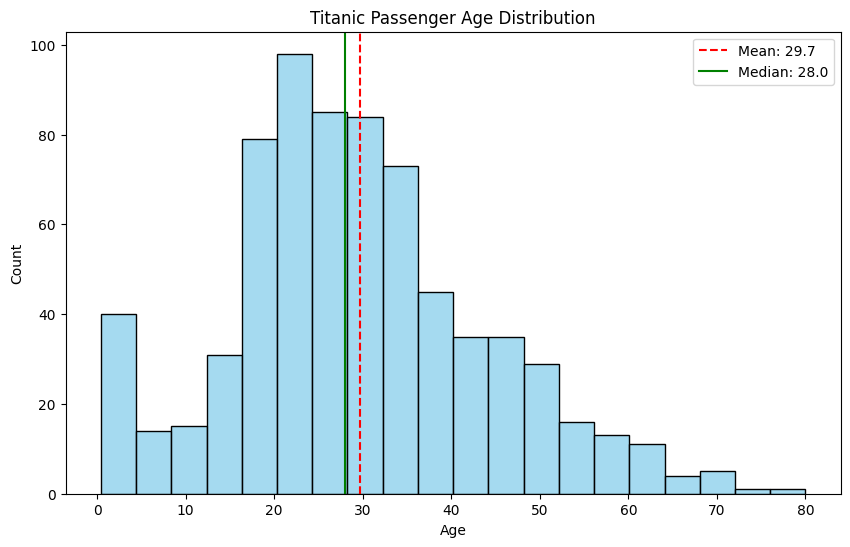

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(train['Age'], color='skyblue')

plt.axvline(train['Age'].mean(), color='red', linestyle='--', label=f"Mean: {train['Age'].mean():.1f}")
plt.axvline(train['Age'].median(), color='green', linestyle='-', label=f"Median: {train['Age'].median():.1f}")

plt.title('Titanic Passenger Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

## **2. Preprocessing**

### **Missing Value**

In [5]:
Age_median = train['Age'].median()
print(Age_median)

train['Age'] = train['Age'].fillna(Age_median)

28.0


In [6]:
Emb_mode = train['Embarked'].mode()
print(Emb_mode)

train['Embarked'] = train['Embarked'].fillna(Emb_mode)

0    S
Name: Embarked, dtype: object


### **Encoding**

In [7]:
train['Sex'] = train['Sex'].map({'male' : 0, 'female' : 1})
train['Embarked'] = train['Embarked'].map({'S':0, 'C':1, 'Q':2})

print(train[['Sex', 'Embarked']].head())

   Sex  Embarked
0    0       0.0
1    1       1.0
2    1       0.0
3    1       0.0
4    0       0.0


### Features

In [8]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']

X = train[features]
y = train['Survived']

print(X.info())
print(y.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pclass  891 non-null    int64  
 1   Sex     891 non-null    int64  
 2   Age     891 non-null    float64
 3   SibSp   891 non-null    int64  
 4   Parch   891 non-null    int64  
 5   Fare    891 non-null    float64
dtypes: float64(2), int64(4)
memory usage: 41.9 KB
None
<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Survived
Non-Null Count  Dtype
--------------  -----
891 non-null    int64
dtypes: int64(1)
memory usage: 7.1 KB
None


### **Train-Test Split**

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

## **3. Modeling**

### **Baseline Model**

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(n_estimators=100, max_depth=5)
model.fit(X_train, y_train)

val_prediction = model.predict(X_val)
val_accuracy = accuracy_score(y_val, val_prediction)

print(f"{val_accuracy * 100:.2f}")

80.45


## **4. Submit**

### **EDA**

In [31]:
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


### **Preprocessing**

In [32]:
test['Age'] = test['Age'].fillna(train['Age'].median())
test['Fare'] = test['Fare'].fillna(train['Fare'].median())
test['Sex'] = test['Sex'].map({'male': 0, 'female': 1})
test['Embarked'] = test['Embarked'].fillna('S')
test['Embarked'] = test['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

### **Modeling**

In [35]:
X_test = test[features]

predictions = model.predict(X_test)

### **Submit**

In [36]:
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": predictions
})

submission.to_csv('submission.csv', index=False)

### **Result**

**Score : 0.78947**